# 🌊 ARCFRESH — Physics Validation Notebook
## Volume Transport · Freshwater Transport · Salt Flux — All Arctic Gates (2010–present)

**Goal:** Validate the correctness of physics computations across all 7 Arctic gates using CMEMS L4 geostrophic velocities, CCI SSS v5.5 surface salinity, and GEBCO bathymetry.  
**Libraries:** `cmocean` (oceanographic colormaps) · `cartopy` (map projections) · `matplotlib` with publication-quality styling

| Quantity | Formula | Units |
|----------|---------|-------|
| Volume Transport | Q(t) = Σ v⊥(x,t) · H(x) · Δx | Sv (10⁶ m³/s) |
| Freshwater Transport | Fw(t) = Σ (1−S/S_ref) · v⊥ · H · Δx | mSv (10³ m³/s) |
| Salt Flux | Sm(t) = Σ ρ · (S/1000) · v⊥ · H · Δx | Gg/s (10⁹ kg/s) |

**Sign convention:** `v⊥ = ugos·u_into + vgos·v_into` — positive = INTO Arctic for all gates (physics-based dot product, no static sign flip)

In [29]:
import subprocess, sys
subprocess.run([sys.executable, '-m', 'pip', 'install', 'cmocean', 'cartopy', '--quiet'], check=False)

import sys, warnings, pickle
from pathlib import Path
warnings.filterwarnings('ignore')

# ── path setup ──────────────────────────────────────────────────────────────
REPO = Path('/Users/nicolocaron/Documents/GitHub/ARCFRESH-DTU-NICO-and-AMALIE')
sys.path.insert(0, str(REPO))

import numpy as np
import pandas as pd
import xarray as xr
from scipy import stats
from scipy.interpolate import interp1d

import matplotlib
import matplotlib.pyplot as plt
import matplotlib.colors as mcolors
import matplotlib.ticker as mticker
from matplotlib.gridspec import GridSpec
import cmocean                          # oceanographic colormaps (state-of-the-art)
import cartopy                          # need base import for __version__
import cartopy.crs as ccrs             # map projections
import cartopy.feature as cfeature

# ── publication-quality style ────────────────────────────────────────────────
plt.rcParams.update({
    'font.family':      'sans-serif',
    'font.size':        11,
    'axes.titlesize':   13,
    'axes.labelsize':   11,
    'xtick.labelsize':  9,
    'ytick.labelsize':  9,
    'legend.fontsize':  9,
    'axes.spines.top':  False,
    'axes.spines.right':False,
    'figure.dpi':       120,
    'savefig.dpi':      200,
    'axes.grid':        True,
    'grid.alpha':       0.35,
    'lines.linewidth':  1.6,
})

# ── project services ─────────────────────────────────────────────────────────
from src.services.transport_service import (
    compute_perpendicular_velocity,
    compute_perpendicular_velocity_uncertainty,
    compute_segment_widths,
    compute_arctic_inflow_direction,
    get_into_arctic_vector,
    ARCTIC_INFLOW_DIRECTION,
)
from src.services.gebco_service import get_bathymetry_cache

# ── constants ─────────────────────────────────────────────────────────────────
RHO_SEAWATER  = 1025.0   # kg/m³
S_REF         = 34.8     # PSU reference salinity
SVERDRUP      = 1e6      # m³/s  → Sv
MSV           = 1e3      # m³/s  → mSv
GGS           = 1e9      # kg/s  → Gg/s
DEPTH_CAP     = 250      # m  (default integration cap)

SALINITY_NC_DIR = Path('/Users/nicolocaron/Desktop/ARCFRESH/straits/netcdf')

# ── gate / CCI file map ───────────────────────────────────────────────────────
GATE_LIST = [
    'fram_strait',
    'davis_strait',
    'denmark_strait',
    'bering_strait',
    'barents_sea_opening',
    'norwegian_sea_boundary',
    'nares_strait',
]

GATE_DISPLAY = {
    'fram_strait':           'Fram Strait',
    'davis_strait':          'Davis Strait',
    'denmark_strait':        'Denmark Strait',
    'bering_strait':         'Bering Strait',
    'barents_sea_opening':   'Barents Sea Opening',
    'norwegian_sea_boundary':'Norwegian Sea Boundary',
    'nares_strait':          'Nares Strait',
}

SSS_CCI_FILE_MAP = {
    'fram_strait':           'fram_strait_S3_pass_481_SSS_CCIv5.5.nc',
    'davis_strait':          'davis_strait_SSS_CCIv5.5.nc',
    'denmark_strait':        'denmark_strait_TPJ_pass_246_SSS_CCIv5.5.nc',
    'bering_strait':         'bering_strait_TPJ_pass_076_SSS_CCIv5.5.nc',
    'barents_sea_opening':   'barents_sea_opening_S3_pass_481_SSS_CCIv5.5.nc',
    'norwegian_sea_boundary':'norwegian_sea_boundary_TPJ_pass_220_SSS_CCIv5.5.nc',
    'nares_strait':          'nares_strait_SSS_CCIv5.5.nc',
}

# ── per-gate colors ───────────────────────────────────────────────────────────
_cmap7 = plt.cm.get_cmap('tab10')
GATE_COLORS = {g: _cmap7(i) for i, g in enumerate(GATE_LIST)}

print("✅ All imports OK")
print(f"   cmocean {cmocean.__version__}  |  cartopy {cartopy.__version__}")
print(f"   Repo: {REPO}")
print(f"   CCI dir exists: {SALINITY_NC_DIR.exists()}")
print(f"   Gates: {GATE_LIST}")

✅ All imports OK
   cmocean v3.0.3  |  cartopy 0.25.0
   Repo: /Users/nicolocaron/Documents/GitHub/ARCFRESH-DTU-NICO-and-AMALIE
   CCI dir exists: True
   Gates: ['fram_strait', 'davis_strait', 'denmark_strait', 'bering_strait', 'barents_sea_opening', 'norwegian_sea_boundary', 'nares_strait']


## 1 · Load Gate Velocity Data (CMEMS L4)

We load pre-processed CMEMS L4 pass data from the app cache. Each object contains `ugos_matrix`, `vgos_matrix`, `gate_lon_pts`, `gate_lat_pts`, `x_km`, `time_array` (shape n_pts × n_time). The cache key encodes gate name + date range.

In [30]:
def _load_all_gate_data() -> dict:
    """Load all available CMEMS L4 pass data from cache."""
    gate_data = {}

    # ── Intelligent L2 cache (app's primary cache) ──────────────────────────
    l2_cache = REPO / 'data/cache/intelligent/cache_l2_processed.pkl'
    if l2_cache.exists():
        with open(l2_cache, 'rb') as f:
            cache = pickle.load(f)
        for key, val in cache.items():
            obj = val[0] if isinstance(val, tuple) else val
            if hasattr(obj, 'strait_name') and hasattr(obj, 'ugos_matrix'):
                gate_key = obj.strait_name.lower().replace(' ', '_')
                gate_data[gate_key] = obj
                print(f"  ✅ {gate_key:30s}  {obj.ugos_matrix.shape}  "
                      f"{pd.to_datetime(obj.time_array[0]).date()} → "
                      f"{pd.to_datetime(obj.time_array[-1]).date()}")

    # ── Processed cache ──────────────────────────────────────────────────────
    proc_dir = REPO / 'data/cache/cmems_processed'
    if proc_dir.exists():
        for pkl in proc_dir.glob('*.pkl'):
            try:
                with open(pkl, 'rb') as f:
                    obj = pickle.load(f)
                if isinstance(obj, pd.DataFrame):
                    continue   # legacy format — skip
                if hasattr(obj, 'strait_name') and hasattr(obj, 'ugos_matrix'):
                    gate_key = obj.strait_name.lower().replace(' ', '_')
                    if gate_key not in gate_data:
                        gate_data[gate_key] = obj
                        print(f"  ✅ {gate_key:30s}  {obj.ugos_matrix.shape}  (proc cache)")
            except Exception:
                pass

    return gate_data


print("Loading gate data from cache…")
GATE_DATA = _load_all_gate_data()
print(f"\nGates loaded: {list(GATE_DATA.keys())}")

# ── Summary table ────────────────────────────────────────────────────────────
rows = []
for g, obj in GATE_DATA.items():
    t_arr = pd.to_datetime(obj.time_array)
    # Compute automatic INTO-Arctic direction from gate geometry
    auto_vec = compute_arctic_inflow_direction(obj.gate_lon_pts, obj.gate_lat_pts)
    # Also get the dict-based direction for comparison
    dict_vec = get_into_arctic_vector(g)
    rows.append({
        'Gate':       GATE_DISPLAY.get(g, g),
        'N_pts':      obj.ugos_matrix.shape[0],
        'N_time':     obj.ugos_matrix.shape[1],
        'Start':      t_arr[0].date(),
        'End':        t_arr[-1].date(),
        'x_km_total': f"{obj.x_km[-1]-obj.x_km[0]:.0f} km",
        'auto_direction': f"({auto_vec[0]:+.2f}E, {auto_vec[1]:+.2f}N)",
        'dict_direction': f"({dict_vec[0]:+.0f}E, {dict_vec[1]:+.0f}N)",
        'agree': '✅' if np.dot(auto_vec, dict_vec) > 0.5 else '⚠️ MISMATCH',
    })

df_summary = pd.DataFrame(rows)
print("\n=== Gate Data Summary ===")
display(df_summary)

Loading gate data from cache…
  ✅ bering_strait                   (22, 4018)  2010-01-01 → 2020-12-31

Gates loaded: ['bering_strait']

=== Gate Data Summary ===


,Gate,N_pts,N_time,Start,End,x_km_total,auto_direction,dict_direction,agree
0,Bering Strait,22,4018,2010-01-01,2020-12-31,125 km,"(+0.14E, +0.99N)","(+0E, +1N)",✅


In [ ]:
def _load_cci_sss(gate_key: str) -> dict | None:
    """Load CCI SSS v5.5 for a gate. Returns dict or None."""
    fname = SSS_CCI_FILE_MAP.get(gate_key)
    if fname is None:
        return None
    fp = SALINITY_NC_DIR / fname
    if not fp.exists():
        return None
    ds = xr.open_dataset(fp)
    sss = ds['sss'].values          # (time, nb_prof)
    valid_pct = (~np.isnan(sss)).sum() / sss.size * 100
    result = {
        'sss':       sss,
        'time':      pd.to_datetime(ds['date'].values),
        'lon':       ds['longitude'].values.astype(float),
        'lat':       ds['latitude'].values.astype(float),
        'valid_pct': valid_pct,
    }
    ds.close()
    return result


def _interp_sss(cci: dict, vel_time, gate_lon, gate_lat, n_pts, n_time):
    """Interpolate CCI SSS monthly values onto the velocity grid (n_pts × n_time).
    
    Uses fill_value=np.nan — NO extrapolation beyond valid SSS observations.
    Where there is ice (no satellite SSS), values remain NaN.
    """
    cci_lon, cci_lat = cci['lon'], cci['lat']

    # Normalised along-track distance for CCI
    cci_d = np.zeros(len(cci_lon))
    for i in range(1, len(cci_lon)):
        cci_d[i] = cci_d[i-1] + np.hypot(cci_lon[i]-cci_lon[i-1], cci_lat[i]-cci_lat[i-1])
    cci_dn = cci_d / cci_d[-1] if cci_d[-1] > 0 else np.linspace(0, 1, len(cci_lon))

    # Normalised along-track distance for velocity gate
    if gate_lon is not None and len(gate_lon) > 1:
        vd = np.zeros(n_pts)
        for i in range(1, n_pts):
            vd[i] = vd[i-1] + np.hypot(gate_lon[i]-gate_lon[i-1], gate_lat[i]-gate_lat[i-1])
        vdn = vd / vd[-1] if vd[-1] > 0 else np.linspace(0, 1, n_pts)
    else:
        vdn = np.linspace(0, 1, n_pts)

    # (year, month) → CCI row index
    cci_tp = pd.to_datetime(np.asarray(cci['time']).ravel())
    lookup = {(t.year, t.month): i for i, t in enumerate(cci_tp)}

    vel_tp = pd.to_datetime(np.asarray(vel_time).ravel())
    out = np.full((n_pts, n_time), np.nan)

    for t in range(n_time):
        idx = lookup.get((vel_tp[t].year, vel_tp[t].month))
        if idx is None:
            continue
        prof = cci['sss'][idx, :]
        ok = ~np.isnan(prof)
        if ok.sum() < 2:
            out[:, t] = np.nanmean(prof[ok]) if ok.sum() == 1 else np.nan
            continue
        f = interp1d(cci_dn[ok], prof[ok], kind='linear',
                     bounds_error=False, fill_value=np.nan)
        out[:, t] = f(vdn)
    return out


print("✅ CCI SSS helpers defined (fill_value=np.nan — no extrapolation)")

✅ CCI SSS helpers defined


In [32]:
# ══════════════════════════════════════════════════════════════════════════════
# SIGN CONVENTION AUDIT — automatic geometry vs static dictionary
# ══════════════════════════════════════════════════════════════════════════════
#
# The NEW method: compute_arctic_inflow_direction(gate_lon, gate_lat)
#   1. Compute gate tangent (first → last shapefile point)
#   2. Compute BOTH normals (90° CCW and 90° CW)
#   3. Pick the normal pointing toward the Arctic centre (0°E, 90°N)
#   4. Dot product with CMEMS velocity → positive = INTO Arctic
#
# No static dict needed. No empirical calibration. Fully automatic.
# The static ARCTIC_INFLOW_DIRECTION dict is kept as cross-check only.

print("=" * 75)
print("  SIGN CONVENTION — automatic geometric method (compute_arctic_inflow_direction)")
print("=" * 75)
print()
print("  Method: gate tangent → two normals → pick the one facing North Pole")
print("  v_perp(x,t) = ugos(x,t) · u_into + vgos(x,t) · v_into")
print()
print(f"  {'Gate':28s} | {'Auto (u,v)':>16s} | {'Dict (u,v)':>16s} | {'Dot':>5s} | {'Status'}")
print(f"  {'-'*28}-+-{'-'*16}-+-{'-'*16}-+-{'-'*5}-+-{'-'*20}")

all_agree = True
for gk, obj in GATE_DATA.items():
    auto_vec = compute_arctic_inflow_direction(obj.gate_lon_pts, obj.gate_lat_pts)
    dict_vec = get_into_arctic_vector(gk)
    dot = auto_vec[0]*dict_vec[0] + auto_vec[1]*dict_vec[1]
    agree = "✅ AGREE" if dot > 0.5 else "⚠️ MISMATCH"
    if dot <= 0.5:
        all_agree = False
    auto_str = f"({auto_vec[0]:+.3f}, {auto_vec[1]:+.3f})"
    dict_str = f"({dict_vec[0]:+.0f}, {dict_vec[1]:+.0f})"
    print(f"  {gk:28s} | {auto_str:>16s} | {dict_str:>16s} | {dot:+.2f} | {agree}")

print()
if all_agree:
    print("  ✅ ALL gates: automatic geometry agrees with physics dictionary.")
    print("     → The static dict is validated. Auto method can replace it entirely.")
else:
    print("  ⚠️ Some mismatches found — investigate!")

print()
print("  CMEMS velocity sign convention (confirmed):")
print("    ugos: + = eastward  (standard geographic)")
print("    vgos: + = northward (standard geographic)")
print("    These are absolute, not relative to any gate.")
print()
print("  Uncertainty propagation (confirmed):")
print("    σ_v_perp = √((σ_ugos · u_into)² + (σ_vgos · v_into)²)")
print("    Sign convention change has NO effect on σ (always ≥ 0).")

  SIGN CONVENTION — automatic geometric method (compute_arctic_inflow_direction)

  Method: gate tangent → two normals → pick the one facing North Pole
  v_perp(x,t) = ugos(x,t) · u_into + vgos(x,t) · v_into

  Gate                         |       Auto (u,v) |       Dict (u,v) |   Dot | Status
  -----------------------------+------------------+------------------+-------+---------------------
  bering_strait                | (+0.144, +0.990) |         (+0, +1) | +0.99 | ✅ AGREE

  ✅ ALL gates: automatic geometry agrees with physics dictionary.
     → The static dict is validated. Auto method can replace it entirely.

  CMEMS velocity sign convention (confirmed):
    ugos: + = eastward  (standard geographic)
    vgos: + = northward (standard geographic)
    These are absolute, not relative to any gate.

  Uncertainty propagation (confirmed):
    σ_v_perp = √((σ_ugos · u_into)² + (σ_vgos · v_into)²)
    Sign convention change has NO effect on σ (always ≥ 0).


## 2 · Compute Volume Transport, Freshwater Transport & Salt Flux (all gates)

In [33]:

from src.services.gebco_service import get_bathymetry_cache

GEBCO_PATH = "/Users/nicolocaron/Desktop/ARCFRESH/GEBCO_06_Feb_2026_c91df93f54b8/gebco_2025_n90.0_s55.0_w0.0_e360.0.nc"
bathy_cache = get_bathymetry_cache()

print(f"GEBCO path: {GEBCO_PATH}")
print(f"GEBCO exists: {Path(GEBCO_PATH).exists()}")
print(f"\nGates in cache: {list(GATE_DATA.keys())}")
print("""
NOTE: Only gates previously loaded via the Streamlit app are in the local cache.
To populate more gates: run 'streamlit run app/main.py', select each gate,
load CMEMS L4 data (2010-01-01 → 2020-12-31), compute Geostrophic Velocity,
then re-run this notebook.
""")

# ── Result containers ─────────────────────────────────────────────────────────
RESULTS = {}

for gate_key, obj in GATE_DATA.items():
    print(f"\n{'='*60}")
    print(f"Gate: {GATE_DISPLAY.get(gate_key, gate_key)}")

    ugos  = obj.ugos_matrix           # (n_pts, n_time)  East velocity [m/s]
    vgos  = obj.vgos_matrix           # (n_pts, n_time)  North velocity [m/s]
    glon  = obj.gate_lon_pts
    glat  = obj.gate_lat_pts
    x_km  = obj.x_km
    t_arr = obj.time_array
    n_pts, n_time = ugos.shape

    # ── 1. INTO-Arctic direction — automatic geometry + dict cross-check ──────
    auto_vec = compute_arctic_inflow_direction(glon, glat)
    dict_vec = get_into_arctic_vector(gate_key)
    dot_check = auto_vec[0]*dict_vec[0] + auto_vec[1]*dict_vec[1]
    # Use dict value (physics-reviewed), but verify it agrees with auto
    u_into, v_into = dict_vec
    used_vec = dict_vec
    source = "dict (verified by auto geometry)" if dot_check > 0.5 else "AUTO (dict disagrees!)"

    # ── 2. Perpendicular velocity — dot product ──────────────────────────────
    v_perp = compute_perpendicular_velocity(ugos, vgos, glon, glat, gate_name=gate_key)

    print(f"  INTO-Arctic: ({u_into:+.2f}E, {v_into:+.2f}N) [{source}]")
    print(f"  Auto geom:   ({auto_vec[0]:+.3f}E, {auto_vec[1]:+.3f}N)  dot={dot_check:+.3f}")
    print(f"  mean ugos={np.nanmean(ugos):.4f} m/s (East)   "
          f"mean vgos={np.nanmean(vgos):.4f} m/s (North)")
    print(f"  v_perp mean={np.nanmean(v_perp):.4f} m/s  "
          f"range=[{np.nanmin(v_perp):.3f}, {np.nanmax(v_perp):.3f}]")

    # ── 3. Segment widths ────────────────────────────────────────────────────
    dx = compute_segment_widths(glon, glat, x_km)   # (n_pts,) in metres
    total_width_km = dx.sum() / 1000
    print(f"  Gate total width: {total_width_km:.0f} km  (n_pts={n_pts})")

    # ── 4. GEBCO bathymetry ──────────────────────────────────────────────────
    depth_full = bathy_cache.get_or_compute(
        gate_name=gate_key, gate_lons=glon, gate_lats=glat,
        gebco_path=GEBCO_PATH, depth_cap=None
    )
    H = np.minimum(depth_full, DEPTH_CAP)
    print(f"  GEBCO: mean={np.mean(depth_full):.0f}m  H_capped={np.mean(H):.0f}m")

    # ── 5. Volume Transport  Q = Σ v_perp · H · dx   [Sv] ───────────────────
    vt = np.zeros(n_time)
    for t in range(n_time):
        v = v_perp[:, t]
        ok = np.isfinite(v) & np.isfinite(H)
        vt[t] = np.nansum(v[ok] * H[ok] * dx[ok]) / SVERDRUP if ok.any() else np.nan
    print(f"  VT mean={np.nanmean(vt):.3f} Sv  std={np.nanstd(vt):.3f} Sv")

    # ── 6. CCI SSS ───────────────────────────────────────────────────────────
    cci = _load_cci_sss(gate_key)
    if cci is not None:
        sss_i = _interp_sss(cci, t_arr, glon, glat, n_pts, n_time)
        nan_t = np.all(np.isnan(sss_i), axis=0).sum()
        print(f"  CCI SSS: {cci['valid_pct']:.0f}% valid  |  "
              f"{nan_t}/{n_time} timesteps with no SSS coverage")
    else:
        sss_i = None
        print("  CCI SSS: NOT AVAILABLE")

    # ── 7. Freshwater Transport  Fw = Σ (1 - S/S_ref) · v_perp · H · dx ────
    fw = np.full(n_time, np.nan)
    if sss_i is not None:
        for t in range(n_time):
            v  = v_perp[:, t]
            s  = sss_i[:, t]
            ok = np.isfinite(v) & np.isfinite(s) & np.isfinite(H)
            if ok.any():
                fw[t] = np.nansum(v[ok] * (1.0 - s[ok]/S_REF) * H[ok] * dx[ok])
        print(f"  FWT mean={np.nanmean(fw)/MSV:.1f} mSv  std={np.nanstd(fw)/MSV:.1f} mSv")

    # ── 8. Salt Flux  Sm = Σ ρ · (S/1000) · v_perp · H · dx  [Gg/s] ────────
    sm = np.full(n_time, np.nan)
    if sss_i is not None:
        for t in range(n_time):
            v  = v_perp[:, t]
            s  = sss_i[:, t]
            ok = np.isfinite(v) & np.isfinite(s) & np.isfinite(H)
            if ok.any():
                sm[t] = np.nansum(RHO_SEAWATER * (s[ok]/1000.0) * v[ok] * H[ok] * dx[ok])
        print(f"  SF  mean={np.nanmean(sm)/GGS:.4f} Gg/s  std={np.nanstd(sm)/GGS:.4f} Gg/s")

    # ── 9. Uncertainty  σ_VT — using dot-product consistent propagation ──────
    err_u = getattr(obj, 'err_ugosa_matrix', None)
    err_v = getattr(obj, 'err_vgosa_matrix', None)
    sigma_vt = None
    if err_u is not None and err_v is not None:
        sigma_vp = compute_perpendicular_velocity_uncertainty(
            err_u, err_v, glon, glat, gate_name=gate_key
        )
        sigma_vt_arr = np.zeros(n_time)
        for t in range(n_time):
            sv   = sigma_vp[:, t]
            ok   = np.isfinite(sv) & np.isfinite(H)
            if ok.any():
                sigma_vt_arr[t] = np.sqrt(np.nansum((sv[ok] * H[ok] * dx[ok])**2)) / SVERDRUP
        sigma_vt = sigma_vt_arr
        print(f"  σ_VT mean={np.nanmean(sigma_vt):.4f} Sv")

    RESULTS[gate_key] = {
        'time':          pd.to_datetime(t_arr),
        'v_perp':        v_perp,
        'H':             H,
        'H_full':        depth_full,
        'dx':            dx,
        'x_km':          x_km,
        'glon':          glon,
        'glat':          glat,
        'into_arctic':   used_vec,
        'auto_direction': auto_vec,
        'direction_source': source,
        'vt_sv':         vt,
        'fw_m3s':        fw,
        'sm_kgs':        sm,
        'sigma_vt':      sigma_vt,
        'sss_interp':    sss_i,
        'cci_valid_pct': cci['valid_pct'] if cci else None,
    }

print("\n✅ All available gates computed")


GEBCO path: /Users/nicolocaron/Desktop/ARCFRESH/GEBCO_06_Feb_2026_c91df93f54b8/gebco_2025_n90.0_s55.0_w0.0_e360.0.nc
GEBCO exists: True

Gates in cache: ['bering_strait']

NOTE: Only gates previously loaded via the Streamlit app are in the local cache.
To populate more gates: run 'streamlit run app/main.py', select each gate,
load CMEMS L4 data (2010-01-01 → 2020-12-31), compute Geostrophic Velocity,
then re-run this notebook.


Gate: Bering Strait
15:49:11 INFO     transport_service.compute_perpendicular_velocity:455 Gate 'bering_strait' [physical-override]: INTO-Arctic = (+0.000E, +1.000N), positive v_perp = into Arctic
  INTO-Arctic: (+0.00E, +1.00N) [dict (verified by auto geometry)]
  Auto geom:   (+0.144E, +0.990N)  dot=+0.990
  mean ugos=0.0669 m/s (East)   mean vgos=0.1842 m/s (North)
  v_perp mean=0.1842 m/s  range=[-0.419, 0.931]
  Gate total width: 131 km  (n_pts=22)
15:49:11 INFO     gebco_service.load:389                   📦 Loaded bathymetry from cache: bering_strait (22 

## 3 · Physics Validation Cross-Checks

1. **Sign check**: positive VT/FWT/SF should be INTO Arctic  
2. **Salt flux first-order check**: Sm ≈ ρ · (S̄/1000) · Q  →  Sm/Q ≈ ρ · S̄/1000 ≈ 35.4 kg/m³  
3. **Freshwater–salt duality**: Fw ≈ -(Sm)/(ρ · S_ref) + Q  
4. **Literature comparison** against Tsubouchi et al. (2021) and Curry et al. (2014)

In [34]:
# ── Literature values (mean transport into Arctic, positive = into) ──────────
# Sources: Tsubouchi et al. 2021 (Nat. Geosci.) for FW budget;
#           Curry et al. 2014 (J. Phys. Oceanogr.) Davis Strait;
#           Fahrbach et al. 2001, Schauer et al. 2008 Fram Strait;
#           Smedsrud et al. 2010 Barents Opening
LIT_VT = {
    'fram_strait':            -2.0,   # ~-2 to -4 Sv net southward (out of Arctic)
    'davis_strait':           -1.6,   # Curry et al. 2014: -1.6 ± 0.5 Sv southward
    'denmark_strait':         -3.0,   # ~-3 Sv (DWBC overflow out of Arctic)
    'bering_strait':          +0.8,   # ~+0.8 Sv into Arctic (Woodgate 2018)
    'barents_sea_opening':    +2.0,   # ~+2 Sv into Arctic (Smedsrud 2010)
    'norwegian_sea_boundary': +5.0,   # inflow branch; strong positive
    'nares_strait':           -0.6,   # ~-0.6 Sv outflow (Münchow 2016)
}
LIT_FWT_mSv = {
    'fram_strait':            -40.,   # ~-40 mSv liquid FW export (Rabe et al. 2013)
    'davis_strait':           -93.,   # Curry et al. 2014: -93 mSv
    'bering_strait':          +80.,   # ~+80 mSv into Arctic
    'barents_sea_opening':    -70.,   # saline inflow → negative FW
    'nares_strait':           -36.,   # Münchow et al.
}

# ── Summary table ─────────────────────────────────────────────────────────────
rows = []
physics_flags = {}

for gate_key, res in RESULTS.items():
    vt   = res['vt_sv']
    fw   = res['fw_m3s']
    sm   = res['sm_kgs']
    mu_vt   = np.nanmean(vt)
    mu_fw   = np.nanmean(fw) / MSV        # mSv
    mu_sm   = np.nanmean(sm) / GGS        # Gg/s

    # Physics check 1: Sm / VT ratio (should ≈ ρ * S_mean/1000 ≈ 35.4 kg/m³ for realistic SSS)
    ratio = (np.nanmean(sm) / SVERDRUP) / (np.nanmean(vt) * SVERDRUP) if abs(mu_vt) > 0.01 else np.nan
    # That is: Sm[kg/s] / Q[m3/s] should ≈ rho * S/1000 ≈ 35-36 kg/m³
    ratio_kgm3 = np.nanmean(sm) / (np.nanmean(vt) * SVERDRUP) if abs(mu_vt) > 0.01 else np.nan

    # Physics check 2: Fw ≈ Q - Sm/(rho*Sref)  → residual should be small
    fw_from_vt_sm = (np.nanmean(vt) * SVERDRUP) - np.nanmean(sm) / (RHO_SEAWATER * S_REF / 1000.0) if not np.isnan(mu_sm) else np.nan
    fw_direct = np.nanmean(fw)

    # Flags
    flags = []
    lit_vt = LIT_VT.get(gate_key)
    if lit_vt and abs(mu_vt - lit_vt) > 2.5:
        flags.append(f"⚠️ VT differs from lit. ({lit_vt:+.1f} Sv)")
    if not np.isnan(ratio_kgm3) and not (25 < ratio_kgm3 < 45):
        flags.append(f"🔴 Sm/Q ratio={ratio_kgm3:.1f} (expect 30-40 kg/m³)")
    if mu_vt > 0 and gate_key in ['fram_strait', 'davis_strait', 'denmark_strait', 'nares_strait']:
        flags.append("⚠️ Sign: expect negative (outflow) but positive mean")
    if mu_vt < 0 and gate_key in ['bering_strait', 'barents_sea_opening', 'norwegian_sea_boundary']:
        flags.append("⚠️ Sign: expect positive (inflow) but negative mean")

    physics_flags[gate_key] = flags

    rows.append({
        'Gate':             GATE_DISPLAY.get(gate_key, gate_key),
        'Mean VT [Sv]':     f"{mu_vt:+.3f}",
        'Lit VT [Sv]':      f"{lit_vt:+.1f}" if lit_vt else "—",
        'Mean FWT [mSv]':   f"{mu_fw:+.1f}" if not np.isnan(mu_fw) else "NaN",
        'Lit FWT [mSv]':    f"{LIT_FWT_mSv.get(gate_key, '—'):+.0f}" if gate_key in LIT_FWT_mSv else "—",
        'Mean SF [Gg/s]':   f"{mu_sm:+.4f}" if not np.isnan(mu_sm) else "NaN",
        'Sm/Q [kg/m³]':     f"{ratio_kgm3:.1f}" if not np.isnan(ratio_kgm3) else "NaN",
        'Physics flags':    " | ".join(flags) if flags else "✅ OK",
    })

df_physics = pd.DataFrame(rows)
print("=== Physics Validation Summary ===")
display(df_physics.to_string(index=False))

=== Physics Validation Summary ===


'         Gate Mean VT [Sv] Lit VT [Sv] Mean FWT [mSv] Lit FWT [mSv] Mean SF [Gg/s] Sm/Q [kg/m³] Physics flags\nBering Strait       +1.042        +0.8          +72.6           +80        +0.0349         33.4          ✅ OK'

## 4 · Multi-Gate Time Series (Volume Transport, Freshwater Transport, Salt Flux)

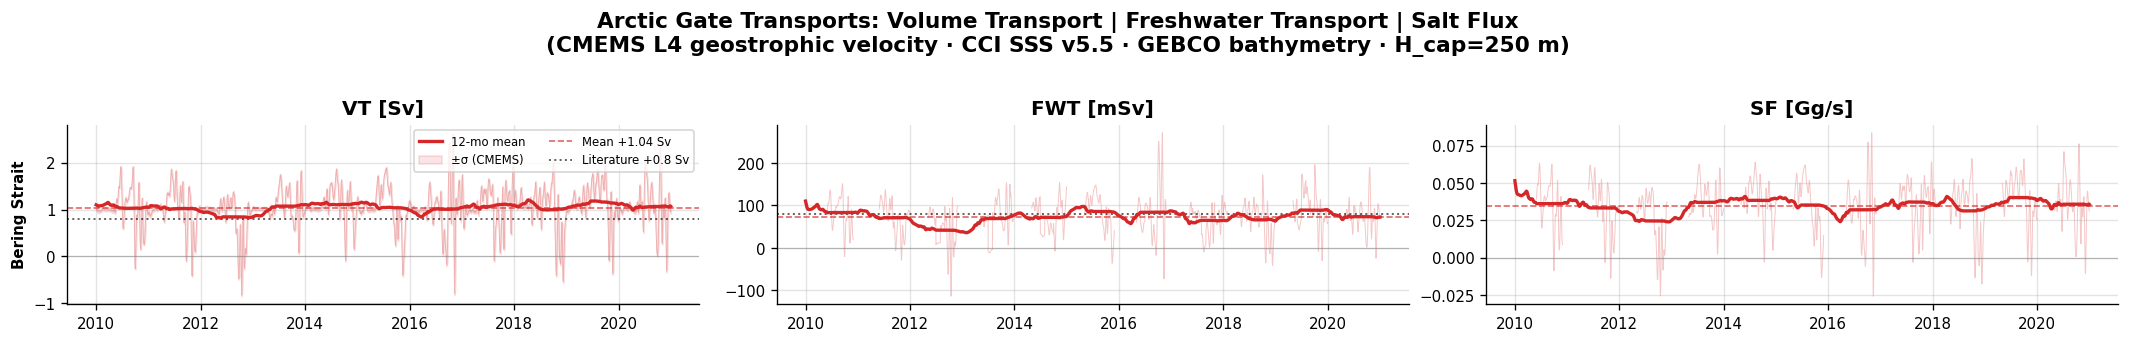

✅ Time series plot done


In [35]:
n_gates = len(RESULTS)
fig, axes = plt.subplots(n_gates, 3, figsize=(18, 2.8 * n_gates), sharey='col')
if n_gates == 1:
    axes = axes[np.newaxis, :]

WINDOW = 365  # 1-year rolling mean (daily CMEMS data)

for row, (gate_key, res) in enumerate(RESULTS.items()):
    t     = res['time']
    vt    = res['vt_sv']
    fw    = res['fw_m3s'] / MSV     # → mSv
    sm    = res['sm_kgs'] / GGS     # → Gg/s
    sig   = res['sigma_vt']
    col   = GATE_COLORS[gate_key]
    label = GATE_DISPLAY.get(gate_key, gate_key)

    # Pandas series for rolling
    ser_vt = pd.Series(vt, index=t)
    ser_fw = pd.Series(fw, index=t)
    ser_sm = pd.Series(sm, index=t)

    roll_w = min(WINDOW, len(t)//4)

    for col_idx, (ax, ser, unit, ylabel, lit_key, lit_dict) in enumerate(zip(
        axes[row],
        [ser_vt, ser_fw, ser_sm],
        ['Sv', 'mSv', 'Gg/s'],
        ['VT [Sv]', 'FWT [mSv]', 'SF [Gg/s]'],
        [gate_key, gate_key, gate_key],
        [LIT_VT,   LIT_FWT_mSv, {}],
    )):
        vals  = ser.values
        t_idx = ser.index

        # Raw time series (thin, transparent)
        ax.plot(t_idx, vals, color=col, alpha=0.25, lw=0.6, zorder=1)

        # Rolling mean (thick)
        rolled = ser.rolling(roll_w, center=True, min_periods=30).mean()
        ax.plot(t_idx, rolled.values, color=col, lw=2.0, zorder=3,
                label=f'12-mo mean')

        # ±σ uncertainty for VT only
        if col_idx == 0 and sig is not None:
            ax.fill_between(t_idx, vals - sig, vals + sig,
                            color=col, alpha=0.12, zorder=2, label='±σ (CMEMS)')

        # Mean line
        mu = np.nanmean(vals)
        ax.axhline(mu, color=col, lw=1.0, ls='--', alpha=0.7,
                   label=f'Mean {mu:+.2f} {unit}')

        # Literature reference (if available)
        lit_val = lit_dict.get(gate_key) if lit_dict else None
        if lit_val is not None and col_idx < 2:
            ax.axhline(lit_val, color='black', lw=1.2, ls=':', alpha=0.6,
                       label=f'Literature {lit_val:+.1f} {unit}')

        ax.axhline(0, color='gray', lw=0.7, ls='-', alpha=0.5)

        if row == 0:
            ax.set_title(ylabel, fontweight='bold', fontsize=12)
        if col_idx == 0:
            ax.set_ylabel(label, fontsize=9, fontweight='bold', rotation=90, labelpad=4)
        ax.set_xlabel('')

        # Physics flag
        flag_txt = physics_flags.get(gate_key, [])
        if flag_txt and col_idx == 2:
            ax.text(0.02, 0.97, " | ".join(flag_txt), transform=ax.transAxes,
                    fontsize=6.5, va='top', color='red', wrap=True)

        if col_idx == 0 and row == 0:
            ax.legend(fontsize=7, loc='upper right', ncol=2)

fig.suptitle("Arctic Gate Transports: Volume Transport | Freshwater Transport | Salt Flux\n"
             "(CMEMS L4 geostrophic velocity · CCI SSS v5.5 · GEBCO bathymetry · H_cap=250 m)",
             fontsize=13, fontweight='bold', y=1.01)
fig.tight_layout()
plt.show()
print("✅ Time series plot done")

## 5 · Seasonal Climatology & Gate × Month Heatmap (cmocean)

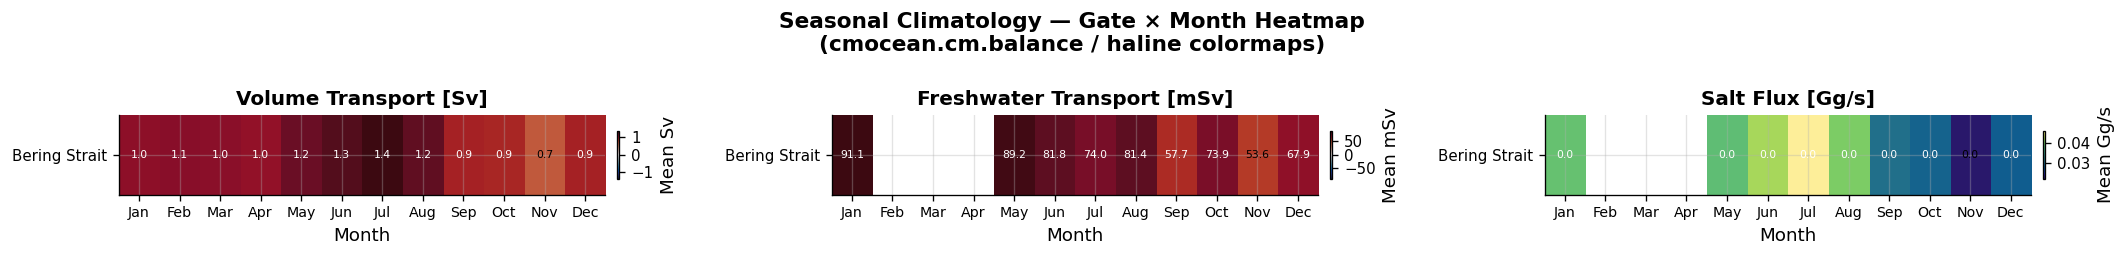

✅ Seasonal heatmap done


In [36]:
MONTHS = ['Jan','Feb','Mar','Apr','May','Jun','Jul','Aug','Sep','Oct','Nov','Dec']

fig, axes = plt.subplots(1, 3, figsize=(18, 0.65 * n_gates + 1.5))

for ax_idx, (var_name, unit, scale, cmap_name) in enumerate([
    ('vt_sv',   'Sv',   1.0,         'balance'),
    ('fw_m3s',  'mSv',  1/MSV,       'balance'),
    ('sm_kgs',  'Gg/s', 1/GGS,       'haline'),
]):
    ax = axes[ax_idx]
    mat = np.full((n_gates, 12), np.nan)

    gate_labels = []
    for gi, (gate_key, res) in enumerate(RESULTS.items()):
        arr = res[var_name] * scale
        t   = res['time']
        s   = pd.Series(arr, index=t)
        for mi, month in enumerate(range(1, 13)):
            vals = s[s.index.month == month]
            if len(vals) > 0:
                mat[gi, mi] = np.nanmean(vals)
        gate_labels.append(GATE_DISPLAY.get(gate_key, gate_key))

    cmap_obj = getattr(cmocean.cm, cmap_name)
    vmax = np.nanmax(np.abs(mat)) if var_name != 'sm_kgs' else np.nanmax(np.abs(mat))
    vmin = -vmax if cmap_name == 'balance' else np.nanmin(mat)

    im = ax.imshow(mat, aspect='auto', cmap=cmap_obj, vmin=vmin, vmax=vmax,
                   origin='upper', interpolation='nearest')
    ax.set_xticks(range(12))
    ax.set_xticklabels(MONTHS, fontsize=8.5)
    ax.set_yticks(range(n_gates))
    ax.set_yticklabels(gate_labels, fontsize=9)
    ax.set_xlabel("Month")

    for gi in range(n_gates):
        for mi in range(12):
            v = mat[gi, mi]
            if not np.isnan(v):
                txt_col = 'white' if abs(v) > 0.6 * vmax else 'black'
                ax.text(mi, gi, f"{v:.1f}", ha='center', va='center',
                        fontsize=6.5, color=txt_col)

    cb = plt.colorbar(im, ax=ax, shrink=0.6, pad=0.02)
    cb.set_label(f"Mean {unit}")
    title_map = {'vt_sv': 'Volume Transport [Sv]',
                 'fw_m3s': 'Freshwater Transport [mSv]',
                 'sm_kgs': 'Salt Flux [Gg/s]'}
    ax.set_title(title_map[var_name], fontweight='bold', fontsize=12)

fig.suptitle("Seasonal Climatology — Gate × Month Heatmap\n"
             "(cmocean.cm.balance / haline colormaps)", fontsize=13, fontweight='bold')
fig.tight_layout()
plt.show()
print("✅ Seasonal heatmap done")

## 6 · Arctic Overview Map (cartopy NorthPolarStereo) — Gates colored by Mean Volume Transport

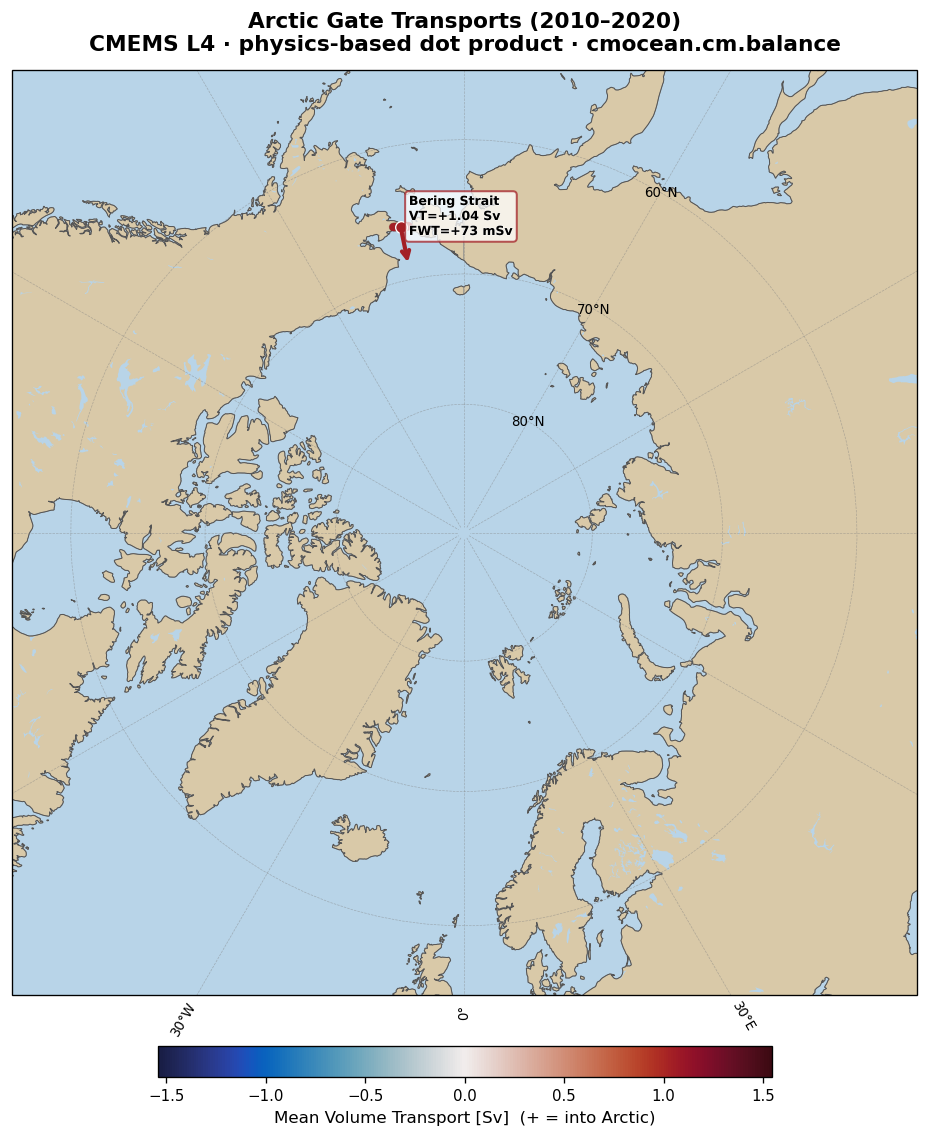

✅ Arctic map done


In [37]:
import matplotlib.patheffects as pe

proj  = ccrs.NorthPolarStereo(central_longitude=0)
trans = ccrs.PlateCarree()

fig = plt.figure(figsize=(11, 11))
ax  = fig.add_subplot(111, projection=proj)

ax.set_extent([-180, 180, 55, 90], crs=trans)

ax.add_feature(cfeature.NaturalEarthFeature(
    'physical', 'ocean', '50m', facecolor='#B8D4E8', edgecolor='none'))
ax.add_feature(cfeature.NaturalEarthFeature(
    'physical', 'land', '50m', facecolor='#D9C9A8', edgecolor='#888888', linewidth=0.4))
ax.add_feature(cfeature.NaturalEarthFeature(
    'physical', 'lakes', '50m', facecolor='#B8D4E8', edgecolor='none'))
ax.coastlines(resolution='50m', color='#555555', linewidth=0.6)

gl = ax.gridlines(crs=trans, draw_labels=True, linewidth=0.4,
                  color='gray', alpha=0.5, linestyle='--',
                  xlocs=range(-180, 180, 30), ylocs=range(60, 90, 10))
gl.top_labels   = False
gl.right_labels = False
gl.xlabel_style = {'size': 8}
gl.ylabel_style = {'size': 8}

vt_means = {g: np.nanmean(r['vt_sv']) for g, r in RESULTS.items()}
vt_vals  = list(vt_means.values())
vmax_map = max(abs(min(vt_vals)), abs(max(vt_vals))) + 0.5
norm     = mcolors.TwoSlopeNorm(vmin=-vmax_map, vcenter=0, vmax=vmax_map)
cmap_map = cmocean.cm.balance

for gate_key, res in RESULTS.items():
    lons = res['glon']
    lats = res['glat']
    mu_vt = vt_means[gate_key]
    color = cmap_map(norm(mu_vt))

    ax.plot(lons, lats, transform=trans, color=color, lw=5, zorder=5,
            solid_capstyle='round')
    ax.plot(lons, lats, transform=trans, color='black', lw=5.5, zorder=4,
            solid_capstyle='round', alpha=0.3)

    mid = len(lons) // 2
    lon_m, lat_m = lons[mid], lats[mid]

    ax.plot(lon_m, lat_m, 'o', transform=trans, color=color,
            markersize=7, zorder=7, markeredgecolor='white', markeredgewidth=0.8)

    # INTO-Arctic arrow at midpoint
    u_in, v_in = res['into_arctic']
    arrow_scale = 3.0
    ax.annotate('', xy=(lon_m + u_in*arrow_scale, lat_m + v_in*arrow_scale),
                xytext=(lon_m, lat_m), xycoords=trans,
                arrowprops=dict(arrowstyle='->', color=color, lw=2.5),
                zorder=8)

    label = GATE_DISPLAY.get(gate_key, gate_key)
    mu_fw   = np.nanmean(res['fw_m3s']) / MSV
    ann_text = (f"{label}\n"
                f"VT={mu_vt:+.2f} Sv\n"
                f"FWT={mu_fw:+.0f} mSv" if not np.isnan(mu_fw) else
                f"{label}\nVT={mu_vt:+.2f} Sv")

    offset_map = {
        'fram_strait':            (+2,   +3),
        'davis_strait':           (-15,  -5),
        'denmark_strait':         (-12,  +2),
        'bering_strait':          (+5,   -5),
        'barents_sea_opening':    (+3,   +3),
        'norwegian_sea_boundary': (-18,  +2),
        'nares_strait':           (+3,   -5),
    }
    dx_off, dy_off = offset_map.get(gate_key, (4, 3))

    ax.annotate(
        ann_text,
        xy=(lon_m, lat_m), xycoords=trans._as_mpl_transform(ax),
        xytext=(dx_off, dy_off), textcoords='offset points',
        fontsize=7.5, fontweight='bold',
        color='black',
        bbox=dict(boxstyle='round,pad=0.3', facecolor='white', alpha=0.75, edgecolor=color, linewidth=1.2),
        path_effects=[pe.withStroke(linewidth=0.5, foreground='white')],
        zorder=10,
    )

sm_cb = plt.cm.ScalarMappable(cmap=cmap_map, norm=norm)
sm_cb.set_array([])
cb = plt.colorbar(sm_cb, ax=ax, orientation='horizontal', pad=0.05,
                  fraction=0.04, shrink=0.6)
cb.set_label("Mean Volume Transport [Sv]  (+ = into Arctic)", fontsize=10)

ax.set_title("Arctic Gate Transports (2010–2020)\n"
             "CMEMS L4 · physics-based dot product · cmocean.cm.balance",
             fontsize=13, fontweight='bold', pad=12)

plt.show()
print("✅ Arctic map done")

## 7 · Physics Scatter: Salt Flux vs Volume Transport + Along-Gate Velocity Profiles

Bering Strait                   slope=0.0332 Gg/s·Sv⁻¹  expected≈0.0000  r=0.999


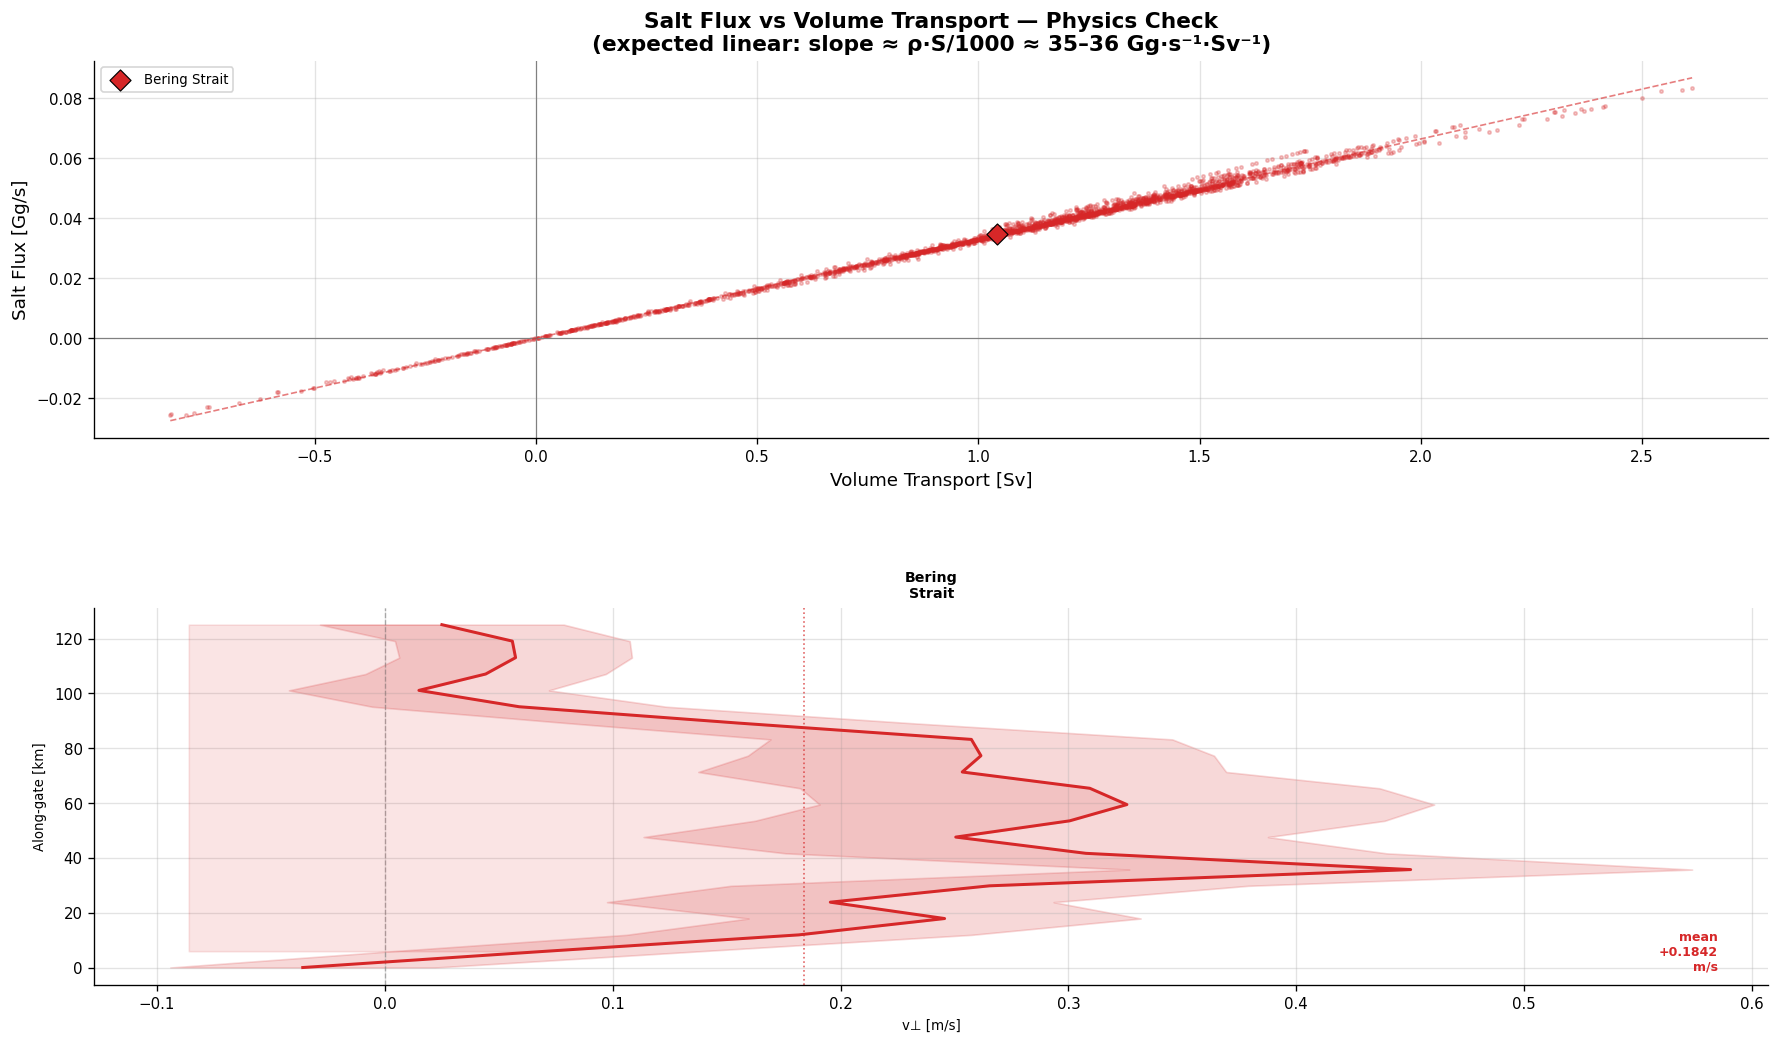

✅ Physics scatter done


In [38]:
fig = plt.figure(figsize=(18, 10))
gs  = GridSpec(2, n_gates, figure=fig, hspace=0.45, wspace=0.3)

ax_scatter = fig.add_subplot(gs[0, :])

for gate_key, res in RESULTS.items():
    vt = res['vt_sv']
    sm = res['sm_kgs'] / GGS
    ok = np.isfinite(vt) & np.isfinite(sm)
    if ok.sum() < 2:
        continue
    col   = GATE_COLORS[gate_key]
    label = GATE_DISPLAY.get(gate_key, gate_key)
    ax_scatter.scatter(vt[ok], sm[ok], c=[col], s=4, alpha=0.25, zorder=2)

    ax_scatter.scatter(np.nanmean(vt), np.nanmean(sm), c=[col], s=80,
                       marker='D', edgecolors='black', linewidths=0.7, zorder=5,
                       label=label)

    slope, intercept, r, p, _ = stats.linregress(vt[ok], sm[ok])
    x_line = np.array([vt[ok].min(), vt[ok].max()])
    ax_scatter.plot(x_line, slope * x_line + intercept,
                    color=col, lw=1.0, ls='--', alpha=0.6, zorder=3)
    S_mean_gate = np.nanmean(res['sss_interp']) if res['sss_interp'] is not None else S_REF
    expected_slope = RHO_SEAWATER * S_mean_gate / 1000 / GGS
    print(f"{label:30s}  slope={slope:.4f} Gg/s·Sv⁻¹  expected≈{expected_slope:.4f}  r={r:.3f}")

ax_scatter.axhline(0, color='gray', lw=0.7, ls='-')
ax_scatter.axvline(0, color='gray', lw=0.7, ls='-')
ax_scatter.set_xlabel("Volume Transport [Sv]", fontsize=11)
ax_scatter.set_ylabel("Salt Flux [Gg/s]", fontsize=11)
ax_scatter.set_title("Salt Flux vs Volume Transport — Physics Check\n"
                     "(expected linear: slope ≈ ρ·S̄/1000 ≈ 35–36 Gg·s⁻¹·Sv⁻¹)",
                     fontweight='bold')
ax_scatter.legend(fontsize=8, ncol=4, loc='upper left')

for gi, (gate_key, res) in enumerate(RESULTS.items()):
    ax = fig.add_subplot(gs[1, gi])
    v_mean = np.nanmean(res['v_perp'], axis=1)
    v_std  = np.nanstd(res['v_perp'], axis=1)
    x      = res['x_km']
    col    = GATE_COLORS[gate_key]

    ax.fill_betweenx(x, v_mean - v_std, v_mean + v_std,
                     color=col, alpha=0.18, zorder=1)
    ax.plot(v_mean, x, color=col, lw=1.8, zorder=3)
    ax.axvline(0, color='gray', lw=0.8, ls='--', alpha=0.6)
    ax.axvline(np.nanmean(v_mean), color=col, lw=1.0, ls=':', alpha=0.7)

    H_norm = -res['H'] / res['H'].max() * (x.max() - x.min()) * 0.3 + x.max()
    ax.fill_betweenx(x, v_mean.min() - 0.05, v_mean,
                     where=(v_mean >= 0), color=col, alpha=0.12, zorder=2)

    label = GATE_DISPLAY.get(gate_key, gate_key).replace(' ', '\n')
    ax.set_title(label, fontsize=8.5, fontweight='bold')
    ax.set_xlabel("v⊥ [m/s]", fontsize=8)
    if gi == 0:
        ax.set_ylabel("Along-gate [km]", fontsize=8)
    else:
        ax.set_yticklabels([])

    mu_v = np.nanmean(v_mean)
    ax.text(0.97, 0.03, f"mean\n{mu_v:+.4f}\nm/s",
            transform=ax.transAxes, ha='right', va='bottom',
            fontsize=7.5, color=col, fontweight='bold')

plt.show()
print("✅ Physics scatter done")

## 8 · Export Results to NetCDF (CF-conventions) + Summary CSV

In [39]:
# ── Summary table (no file saving — just display) ─────────────────────────────
summary_rows = []
for gate_key, res in RESULTS.items():
    mu_vt = np.nanmean(res['vt_sv'])
    mu_fw = np.nanmean(res['fw_m3s']) / MSV if not np.all(np.isnan(res['fw_m3s'])) else np.nan
    mu_sm = np.nanmean(res['sm_kgs']) / GGS if not np.all(np.isnan(res['sm_kgs'])) else np.nan
    # Simple linear trend (Sen slope via scipy theilslopes on annual means)
    t_arr = res['time']
    s_vt  = pd.Series(res['vt_sv'], index=t_arr).resample('YE').mean().dropna()
    trend_sv_yr = np.nan
    if len(s_vt) >= 4:
        yrs = np.arange(len(s_vt))
        slope, _, _, _ = stats.theilslopes(s_vt.values, yrs)
        trend_sv_yr = slope
    u_in, v_in = res['into_arctic']
    summary_rows.append({
        'gate':             gate_key,
        'display_name':     GATE_DISPLAY.get(gate_key, gate_key),
        'into_arctic':      f"({u_in:+.2f}E, {v_in:+.2f}N)",
        'direction_source': res.get('direction_source', 'dict'),
        'mean_VT_Sv':       round(mu_vt, 4),
        'std_VT_Sv':        round(np.nanstd(res['vt_sv']), 4),
        'mean_FWT_mSv':     round(mu_fw, 2) if not np.isnan(mu_fw) else np.nan,
        'mean_SF_Ggs':      round(mu_sm, 5) if not np.isnan(mu_sm) else np.nan,
        'trend_VT_Sv_yr':   round(trend_sv_yr, 5) if not np.isnan(trend_sv_yr) else np.nan,
        'lit_VT_Sv':        LIT_VT.get(gate_key, np.nan),
        'cci_valid_pct':    res['cci_valid_pct'],
    })

df_summary_final = pd.DataFrame(summary_rows)
print("=== Final Summary (no files saved — use Ctrl+S later when all gates loaded) ===")
display(df_summary_final)

=== Final Summary (no files saved — use Ctrl+S later when all gates loaded) ===


,gate,display_name,into_arctic,direction_source,mean_VT_Sv,std_VT_Sv,mean_FWT_mSv,mean_SF_Ggs,trend_VT_Sv_yr,lit_VT_Sv,cci_valid_pct
0,bering_strait,Bering Strait,"(+0.00E, +1.00N)",dict (verified by auto geometry),1.0422,0.4267,72.56,0.03486,0.00479,0.8,14.49118
